# Modelo TCN+CNN-ae


 TCN + Actor-Critic sobre CNN-AE  —  Agente semáforo bursátil
 Prototipo: segunda etapa del pipeline (requiere cnn_ae_weights.pth)

 ¿Qué hace este módulo (Explicado de forma resumida)?
 1. Carga el CNN-AE entrenado y lo usa SOLO como extractor de features (frozen).
 2. Construye una TCN causal-dilatada que modela la evolución temporal de z.
 3. Añade una cabeza Actor-Critic ligera (PPO-style) que emite BUY/SELL/HOLD.
 4. Entrena con una recompensa sencilla basada en retorno ajustado por riesgo.
 5. Visualiza el semáforo sobre el período de test.




In [ ]:
# ── 0. Instalación (ejecutar solo la primera vez) ────────────────────────────
# 1) Reinstala limpio el par numpy+scipy con ABI emparejada (arregla el import roto).
#    numpy<2.3 porque numba (dependencia de pandas_ta 0.4.x) aún no soporta 2.3.
!pip install -q --force-reinstall "numpy<2.3" scipy

# 2) Resto del stack, evitando el salto roto a pandas 3.0.
!pip install -q "pandas<3" numba yfinance pandas_ta torch torchvision

# Reinicia el kernel para que cargue el numpy nuevo desde disco.
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 19.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.0 MB/s eta 0:00:00
Requested yfinance from https://files.pythonhosted.org/packages/f3/23/0e28fa29eba03f33d74c58296f301064930340622be34b008ed02d4486de/yfinance-0.1.91-py2.py3-none-any.whl has invalid metadata: Expected matching RIGHT_PARENTHESIS for LEFT_PARENTHESIS, after version specifier
    appdirs (>=1.4.4cryptography>=3.3.2)
            ~~~~~~~~~~^
Pl

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

import yfinance as yf
import pandas_ta as ta
from sklearn.preprocessing import MinMaxScaler
# ──────────────────────────────────────────────────────────────────────────────
# PARÁMETROS GLOBALES
# ──────────────────────────────────────────────────────────────────────────────
TICKER        = "^IBEX"
START_DATE    = "2000-01-01"
END_DATE      = "2024-12-31"
STABILITY_END = "2019-12-31"
WINDOW_SIZE   = 30
FEATURE_COLS  = ["Log_Ret", "Volatilidad", "RSI_14", "MACD_12_26_9", "SMA_50"]

TCN_SEQ_LEN   = 10
TCN_CHANNELS  = [32, 16]
TCN_KERNEL    = 3
TCN_DROPOUT   = 0.3

EPOCHS        = 300
LR            = 3e-4
WEIGHT_DECAY  = 1e-3
LABEL_SMOOTH  = 0.05
LAMBDA_REG    = 10.0       # peso de la pérdida de regresión (multitarea)

HORIZON       = 8         # días vista para la dirección
LABEL_THR     = 0.0
COVERAGE      = 0.60       # fracción de días con señal direccional (resto HOLD)

# Filtro de tendencia
GATE_FAST     = 20
GATE_DD_LOOK  = 10
GATE_DD_THR   = -0.05

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {DEVICE}")


Dispositivo: cuda


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. CNN-AE FROZEN
# ══════════════════════════════════════════════════════════════════════════════

class ConvAutoencoder(nn.Module):
    def __init__(self, n_features, seq_len=30):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 32, 3, 1, 1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 16, 3, 2, 1), nn.BatchNorm1d(16), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 32, 3, 2, 1, output_padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, n_features, 3, 1, 1), nn.Sigmoid(),
        )

    def encode(self, x):       return self.encoder(x.permute(0, 2, 1))
    def get_latent_flat(self, x): return self.encode(x).flatten(1)
    def forward(self, x):      return self.decoder(self.encode(x)).permute(0, 2, 1)


def load_cnn_ae(path, n_features, device):
    m = ConvAutoencoder(n_features)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    for p in m.parameters():
        p.requires_grad = False
    return m.to(device)


1. Reutilizar el CNN-AE como extractor de features
El autoencoder de la fase anterior aprendió a comprimir 30 días de mercado en un vector latente z. Aquí lo reciclamos como extractor de características: no nos interesa su capacidad de reconstrucción, sino el vector comprimido del encoder.
Decisiones clave:

Congelamos los pesos (requires_grad = False). El CNN-AE ya aprendió lo que tenía que aprender; tocarlo ahora destruiría esa información.
El método get_latent_flat aplana el tensor (B, 16, 15) que produce el encoder en un vector (B, 240). Esto facilita que la TCN trabaje con un único vector por día.
Usamos model.eval() para desactivar BatchNorm y Dropout en modo entrenamiento.

Ventaja del enfoque modular: podemos cambiar el CNN-AE por otro extractor (un transformer, una VAE...) sin tocar el resto del pipeline.

<img src="frozenCNN.jpeg">



In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. TCN
# ══════════════════════════════════════════════════════════════════════════════

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad = (kernel - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=0)
    def forward(self, x):
        return self.conv(F.pad(x, (self.pad, 0)))


class ResidualTCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, kernel, dilation),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, kernel, dilation),
            nn.BatchNorm1d(out_ch), nn.ReLU(), nn.Dropout(dropout),
        )
        self.downsample = (nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity())
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.net(x) + self.downsample(x))


class TCN(nn.Module):
    def __init__(self, input_dim, channels, kernel=3, dropout=0.1, output_dim=64):
        super().__init__()
        layers, in_ch = [], input_dim
        for i, out_ch in enumerate(channels):
            layers.append(ResidualTCNBlock(in_ch, out_ch, kernel, 2 ** i, dropout))
            in_ch = out_ch
        self.tcn  = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], output_dim)
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.tcn(x)[:, :, -1]
        return self.head(x)


2. Temporal Convolutional Network (TCN)
La TCN modela cómo evolucionan los vectores z en el tiempo. Frente a un LSTM, ofrece tres ventajas decisivas: paralelización (es una conv 1D), gradientes estables y campo receptivo controlable.
Se compone de tres piezas:
CausalConv1d — Una convolución 1D con padding asimétrico: solo añadimos ceros por la izquierda del tensor. Resultado: en el instante t el filtro solo puede ver t, t-1, t-2…, jamás el futuro. Crítico para no hacer lookahead en series financieras.
ResidualTCNBlock — Dos CausalConv1d en serie con BatchNorm, ReLU y Dropout, más una conexión residual (suma de la entrada). La conexión residual estabiliza el gradiente cuando apilamos varios bloques. Si los canales de entrada y salida difieren, una conv 1×1 (downsample) ajusta la dimensión antes de sumar.
TCN — Apila bloques con dilatación que crece exponencialmente (1, 2, 4, 8…). Cada bloque ve el doble de pasos atrás que el anterior, así que el campo receptivo crece exponencialmente con la profundidad sin disparar el coste.
Fórmula del campo receptivo: RF=1+2(K−1)∑i=0k−12iRF = 1 + 2(K-1)\sum_{i=0}^{k-1} 2^i
RF=1+2(K−1)∑i=0k−1​2i. Con K=3 y k=3 bloques → RF = 29, casi un mes de z consecutivos.
Tras la pila tomamos solo x[:, :, -1] (el último timestep, que ya ha integrado toda la historia) y lo proyectamos a un vector de contexto de 64 dimensiones.

<img src="TCNbloques.jpeg">

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. AGENTE MULTITAREA: clasificación direccional + regresión de retorno
# ══════════════════════════════════════════════════════════════════════════════

class SemaforoAgent(nn.Module):
    ACTION_NAMES = {0: "HOLD", 1: "BUY", 2: "SELL"}

    def __init__(self, cnn_ae, z_dim=246, tcn_channels=None, tcn_kernel=3,
                 tcn_seq_len=10, dropout=0.3, context_dim=64):
        super().__init__()
        if tcn_channels is None:
            tcn_channels = [32, 16]
        self.cnn_ae = cnn_ae
        self.tcn = TCN(z_dim, tcn_channels, tcn_kernel, dropout, context_dim)
        self.cls = nn.Sequential(nn.Linear(context_dim, 64), nn.ReLU(), nn.Linear(64, 3))
        self.reg = nn.Sequential(nn.Linear(context_dim, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, z):
        ctx = self.tcn(z)
        return self.cls(ctx), self.reg(ctx).squeeze(-1)   # logits (B,3), r_pred (B,)


3. SemaforoAgent: agente multitarea
Esta clase define una red neuronal en PyTorch (nn.Module) que toma la representación comprimida del mercado a lo largo del tiempo y produce dos salidas a la vez: una decisión direccional y una predicción numérica del retorno. Es multitarea porque resuelve dos problemas distintos —clasificación y regresión— compartiendo la misma columna vertebral.
El nombre "semáforo" viene de las tres acciones posibles, como las tres luces de un semáforo: HOLD (esperar), BUY (comprar) y SELL (vender). Eso es lo que guarda el diccionario ACTION_NAMES.
Componentes que se construyen en __init__:

cnn_ae: el autoencoder convolucional (ya entrenado) que comprime cada "foto" del mercado en un vector latente z. Se guarda como parte del módulo, pero fíjate que no se usa dentro de forward —la codificación se hace fuera, y aquí entra la z ya codificada.
tcn: una Red Convolucional Temporal (TCN). Recibe la secuencia de vectores latentes (la evolución en el tiempo) y la resume en un único vector de contexto ctx de dimensión context_dim=64. Es la parte que captura los patrones temporales.
cls (cabeza de clasificación): dos capas lineales con una ReLU en medio (64 → 64 → 3). Produce 3 logits, uno por acción.
reg (cabeza de regresión): misma estructura pero termina en 1 número (64 → 64 → 1). Predice el retorno esperado.

La clave del diseño es que ambas cabezas comparten el mismo ctx: el TCN aprende una representación útil para las dos tareas a la vez, lo que suele mejorar la generalización (el aprendizaje multitarea actúa como regularización).
Qué hace forward(z):

ctx = self.tcn(z) — el TCN procesa la secuencia latente y devuelve el contexto de forma (B, 64).
Devuelve una tupla con dos cosas:

self.cls(ctx) → logits de forma (B, 3). Todavía no son probabilidades; habría que aplicar softmax para interpretarlos o argmax para elegir la acción.
self.reg(ctx).squeeze(-1) → retorno predicho de forma (B,). El squeeze(-1) elimina la dimensión sobrante: convierte (B, 1) en (B,).



(B es el tamaño del batch.) Un par de detalles menores: los hiperparámetros z_dim=246 y dropout=0.3 configuran la dimensión latente y la regularización; y tcn_seq_len=10 se acepta como argumento pero no se pasa al constructor del TCN en este fragmento, así que ahí no tiene efecto.

La idea central que conviene anotar: una sola columna vertebral (el TCN) alimenta dos cabezas distintas. El TCN resume la historia temporal en ctx, y a partir de ese mismo vector salen las dos predicciones —qué hacer (semáforo) y cuánto se espera ganar (retorno)—. Por eso el return del forward entrega una tupla con las dos salidas a la vez.

<img src="semaforo_agent_arquitectura.png">

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. DATOS
# ══════════════════════════════════════════════════════════════════════════════

def build_zf_sequences(cnn_ae, X_windows, feat_windows, tcn_seq_len, device, batch_size=256):
    cnn_ae.eval()
    all_z = []
    for i in range(0, len(X_windows), batch_size):
        batch = torch.tensor(X_windows[i:i+batch_size], dtype=torch.float32).to(device)
        with torch.no_grad():
            all_z.append(cnn_ae.get_latent_flat(batch).cpu().numpy())
    all_z  = np.concatenate(all_z, axis=0).astype(np.float32)
    all_zf = np.concatenate([all_z, feat_windows.astype(np.float32)], axis=1)
    return np.array([all_zf[i:i+tcn_seq_len] for i in range(len(all_zf) - tcn_seq_len)])


def forward_returns(close, decision_offset, n_seqs, horizon):
    c = close.values.astype(np.float64)
    out = []
    for i in range(n_seqs):
        d = decision_offset + i
        if d + horizon >= len(c):
            break
        out.append(np.log(c[d + horizon] / c[d]))
    return np.asarray(out, dtype=np.float32)


def make_labels(fwd, thr=0.0):
    y = np.zeros(len(fwd), dtype=np.int64)
    y[fwd >  thr] = 1
    y[fwd < -thr] = 2
    return y


4.1  build_zf_sequences: de ventanas crudas a secuencias para el TCN
Esta función convierte las ventanas crudas del mercado en las secuencias temporales que consumirá el TCN. El proceso es:

cnn_ae.eval() pone el autoencoder en modo evaluación (desactiva dropout y congela las estadísticas de batchnorm), porque aquí solo se usa para codificar, no para entrenar.
El bucle recorre X_windows en lotes de 256 para no saturar la memoria. Cada lote se pasa a tensor, se mueve al device (GPU/CPU) y dentro de torch.no_grad() —sin construir el grafo de gradientes, más rápido y ligero— se codifica con cnn_ae.get_latent_flat(batch), que devuelve el vector latente aplanado z de cada ventana. Se vuelca a CPU como NumPy y se acumula.
all_z = np.concatenate(...) apila todos los latentes en una matriz (N, dim_latente).
all_zf = np.concatenate([all_z, feat_windows], axis=1) pega lateralmente el latente con tus features hechas a mano (axis=1 = eje de columnas/características). El resultado zf es "z + features"; ese ancho combinado es el z_dim=246 que veías en el agente.
El return arma ventanas deslizantes de longitud tcn_seq_len: all_zf[i:i+tcn_seq_len] para cada i. Cada elemento es una secuencia de tcn_seq_len pasos consecutivos, así que la salida tiene forma (N - tcn_seq_len, tcn_seq_len, 246). Eso es exactamente lo que espera el TCN.

<img src="build_zf_sequences_pipeline.png">

4.2. forward_returns y make_labels: construir los objetivos
Mientras la función anterior fabrica la entrada (X), estas dos fabrican lo que el modelo debe predecir (las dos cabezas del agente).
forward_returns(close, decision_offset, n_seqs, horizon) calcula, para cada punto de decisión, cuánto se mueve el precio en el futuro:

c = close.values toma la serie de precios de cierre.
Para cada secuencia i, el índice real en la serie es d = decision_offset + i. Ese decision_offset es clave: alinea cada secuencia con el precio correcto, compensando los puntos que se "comieron" al crear las ventanas. Así se evita mirar el futuro por error (look-ahead bias).
Si d + horizon >= len(c) no hay suficiente futuro y se corta el bucle.
np.log(c[d + horizon] / c[d]) es el retorno logarítmico a horizon pasos vista: el log del precio futuro dividido por el actual. Ese valor es directamente el objetivo de la cabeza de regresión (r_pred).

make_labels(fwd, thr=0.0) discretiza esos retornos en las 3 clases del semáforo:

Empieza todo a 0 (HOLD).
Donde el retorno supera +thr → 1 (BUY, el precio sube).
Donde cae por debajo de -thr → 2 (SELL, el precio baja).
thr es una zona muerta: si subes thr, exiges un movimiento mínimo para no quedarte en HOLD (con thr=0.0 casi nada cae en HOLD). El resultado y es el objetivo de la cabeza de clasificación.

<img src="forward_returns_y_make_labels.png">

La idea que conviene anotar para enlazar con el bloque anterior: el mismo retorno futuro fwd alimenta las dos cabezas del agente. Tal cual (número continuo) es el objetivo de la regresión; discretizado por make_labels es el objetivo de la clasificación. Así, las secuencias del primer pipeline son la X, y fwd + y son las dos Y que el SemaforoAgent aprende a predecir a la vez.

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. ENTRENAMIENTO MULTITAREA (CE direccional + MSE de retorno)
# ══════════════════════════════════════════════════════════════════════════════

def train_supervised(agent, z_train, fwd_train, r1_train, epochs=300, lr=3e-4,
                     weight_decay=1e-3, thr=0.0, val_frac=0.2, batch_size=128,
                     patience=40, min_epochs=40, label_smoothing=0.05,
                     lambda_reg=10.0, device="cpu"):
    y_all = make_labels(fwd_train, thr)
    n_val = int(len(z_train) * val_frac)
    Xtr = torch.as_tensor(z_train[:-n_val], dtype=torch.float32, device=device)
    ytr = torch.as_tensor(y_all[:-n_val],   dtype=torch.long,    device=device)
    rtr = torch.as_tensor(r1_train[:-n_val], dtype=torch.float32, device=device)
    Xva = torch.as_tensor(z_train[-n_val:], dtype=torch.float32, device=device)
    yva = torch.as_tensor(y_all[-n_val:],   dtype=torch.long,    device=device)
    rva = torch.as_tensor(r1_train[-n_val:], dtype=torch.float32, device=device)
    fwd_va = fwd_train[-n_val:]

    params = list(agent.tcn.parameters()) + list(agent.cls.parameters()) + list(agent.reg.parameters())
    opt = Adam(params, lr=lr, weight_decay=weight_decay)

    n = Xtr.shape[0]
    best_loss, best_state, best_ep, bad = float("inf"), None, 0, 0
    val_acc_hist = []
    for ep in range(epochs):
        agent.train()
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            logits, rpred = agent(Xtr[idx])
            loss = (F.cross_entropy(logits, ytr[idx], label_smoothing=label_smoothing)
                    + lambda_reg * F.mse_loss(rpred, rtr[idx]))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, 1.0); opt.step()

        agent.eval()
        with torch.no_grad():
            vlogits, vrpred = agent(Xva)
            vloss = (F.cross_entropy(vlogits, yva, label_smoothing=label_smoothing)
                     + lambda_reg * F.mse_loss(vrpred, rva)).item()
            vpred = vlogits.argmax(1).cpu().numpy()
        traded  = (vpred == 1) | (vpred == 2)
        correct = ((vpred == 1) & (fwd_va > 0)) | ((vpred == 2) & (fwd_va < 0))
        vacc = correct[traded].mean() if traded.sum() else float("nan")
        val_acc_hist.append(vacc)

        if vloss < best_loss - 1e-4:
            best_loss, best_ep, bad = vloss, ep, 0
            best_state = {k: v.detach().clone() for k, v in agent.state_dict().items()}
        else:
            bad += 1
        if (ep + 1) % 20 == 0:
            print(f"  Ep {ep+1:>3}/{epochs} | val_loss={vloss:.4f} | val_acc={vacc:.3f}")
        if ep + 1 >= min_epochs and bad >= patience:
            print(f"  Early stopping en epoch {ep+1}")
            break

    if best_state is not None:
        agent.load_state_dict(best_state)
    print(f"  Checkpoint: época {best_ep+1} | val_loss={best_loss:.4f} | val_acc={val_acc_hist[best_ep]:.3f}")
    return val_acc_hist, best_ep


5. Preparación (antes del bucle)

y_all = make_labels(fwd_train, thr) genera las etiquetas direccionales a partir de los retornos.
n_val = int(len(z_train) * val_frac) reserva el 20 % final para validación. El reparto es temporal, no aleatorio: [:-n_val] es entrenamiento y [-n_val:] es validación. En series temporales esto es obligatorio para no "ver el futuro" durante el entrenamiento.
Se crean tres tensores por conjunto: X (las secuencias), y (etiquetas, tipo long) y r (retorno, objetivo de regresión). Fíjate en que hay dos señales de retorno distintas: r1_train alimenta el objetivo de regresión (rtr/rva), y fwd_train se usa para las etiquetas y para la métrica de validación (fwd_va se guarda en NumPy).
params = tcn + cls + reg y opt = Adam(params, ...). Detalle clave: el autoencoder no aparece en params, así que el encoder queda congelado y solo se entrenan el TCN y las dos cabezas. weight_decay añade regularización L2.

La pérdida multitarea
Por cada lote, el agente produce logits y rpred, y la pérdida los junta:

F.cross_entropy(logits, y, label_smoothing=0.05) para la dirección. El label_smoothing suaviza las etiquetas (en vez de 1.0 / 0.0 usa algo como 0.95 / 0.025), lo que reduce el exceso de confianza y suele mejorar la generalización.
lambda_reg * F.mse_loss(rpred, r) para el retorno. lambda_reg=10.0 pondera fuerte la regresión frente a la clasificación, para que ambas tareas pesen de forma comparable.

Esto es lo que comparte la columna vertebral: las dos pérdidas se suman y retropropagan a la vez.

<img src="perdida_multitarea_ce_mse.png">

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. INFERENCIA (selectividad por cobertura), FILTRO Y MÉTRICAS
# ══════════════════════════════════════════════════════════════════════════════

SEMAFORO_COLORS = {0: ("#f59e0b", "HOLD"), 1: ("#22c55e", "BUY"), 2: ("#ef4444", "SELL")}

def run_inference(agent, z_sequences, dates, device, coverage=0.30):
    """
    Señala BUY/SELL solo en los días de mayor confianza (colas del score
    s=P(BUY)-P(SELL)). 'coverage' = fracción de días con señal direccional.
    Devuelve también r_pred para las métricas de regresión.
    """
    agent.eval()
    P, R = [], []
    for i in range(len(z_sequences)):
        x = torch.tensor(z_sequences[i], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            logits, rpred = agent(x)
            P.append(F.softmax(logits, dim=-1).squeeze().cpu().numpy())
            R.append(float(rpred.cpu()))
    P, R = np.array(P), np.array(R)
    score = P[:, 1] - P[:, 2]
    lo = np.quantile(score, coverage / 2)
    hi = np.quantile(score, 1 - coverage / 2)
    actions = np.where(score >= hi, 1, np.where(score <= lo, 2, 0))
    return pd.DataFrame({
        "date": dates[:len(actions)], "action": actions,
        "label": [SEMAFORO_COLORS[a][1] for a in actions],
        "p_hold": P[:, 0], "p_buy": P[:, 1], "p_sell": P[:, 2], "r_pred": R,
    }).set_index("date")



def apply_trend_gate(signals, df, fast=GATE_FAST, dd_look=GATE_DD_LOOK, dd_thr=GATE_DD_THR):
    close = df["Close"]
    sma   = close.rolling(fast).mean()
    ret_r = np.log(close / close.shift(dd_look))
    bullish = ((close > sma) & (ret_r > dd_thr)).reindex(signals.index).fillna(False).values
    act = signals["action"].values.copy()
    act[bullish  & (act == 2)] = 0
    act[~bullish & (act == 1)] = 0
    out = signals.copy()
    out["action"] = act
    out["label"]  = [SEMAFORO_COLORS[a][1] for a in act]
    return out


def evaluate_signals(signals, fwd):
    act = signals["action"].values
    n = len(act); fwd = fwd[:n]
    up, down = fwd > 0, fwd < 0
    bi, se, ho = act == 1, act == 2, act == 0
    traded = bi | se
    correct = (bi & up) | (se & down)
    nt = int(traded.sum())
    pos = np.where(bi, 1.0, np.where(se, -1.0, 0.0))
    return {
        "n_total": n, "n_buy": int(bi.sum()), "n_sell": int(se.sum()), "n_hold": int(ho.sum()),
        "coverage": nt / n if n else float("nan"),
        "dir_accuracy": float(correct[traded].mean()) if nt else float("nan"),
        "precision_buy": (bi & up).sum() / max(int(bi.sum()), 1),
        "precision_sell": (se & down).sum() / max(int(se.sum()), 1),
        "base_up_rate": float(up.mean()),
        "edge_por_senal": float((pos * fwd)[traded].mean()) if nt else float("nan"),
    }


def regression_metrics(pred, true):
    pred, true = np.asarray(pred, float), np.asarray(true, float)
    err = pred - true
    ss_res, ss_tot = np.sum(err ** 2), np.sum((true - true.mean()) ** 2)
    return {
        "R2":   1 - ss_res / ss_tot,
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MAE":  float(np.mean(np.abs(err))),
        "MAPE": float(np.mean(np.abs(err / true)) * 100),
    }


def print_metrics(m, horizon):
    print(f"\n— Acierto direccional (horizonte = {horizon} días) —")
    print(f"   BUY / HOLD / SELL    : {m['n_buy']} / {m['n_hold']} / {m['n_sell']}")
    print(f"   Cobertura (no-ámbar) : {m['coverage']:.3f}")
    print(f"   Accuracy direccional : {m['dir_accuracy']:.3f}")
    print(f"   Precisión BUY        : {m['precision_buy']:.3f}")
    print(f"   Precisión SELL       : {m['precision_sell']:.3f}")
    print(f"   Base 'siempre sube'  : {m['base_up_rate']:.3f}")
    print(f"   Edge medio por señal : {m['edge_por_senal']:+.5f}")


def sweep_coverage(agent, z_test, dates, df, fwd_test, device,
                   covs=(0.6, 0.5, 0.4, 0.3, 0.2, 0.1)):
    print("\n— Barrido accuracy vs cobertura (tras filtro de tendencia) —")
    print("   cobertura_obj | cobertura_real | accuracy | BUY | SELL")
    for c in covs:
        s = apply_trend_gate(run_inference(agent, z_test, dates, device, coverage=c), df)
        m = evaluate_signals(s, fwd_test)
        print(f"        {c:.2f}      |     {m['coverage']:.3f}      |  {m['dir_accuracy']:.3f}  "
              f"| {m['n_buy']:>3} | {m['n_sell']:>3}")


def plot_semaforo(signals, close_prices, title="Semáforo bursátil — IBEX 35"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})
    common = signals.index.intersection(close_prices.index)
    price, sigs = close_prices.loc[common], signals.loc[common]
    ax1.plot(price.index, price.values, color="#1e40af", linewidth=1.2, zorder=3)
    for date, row in sigs.iterrows():
        ax1.axvspan(date, date + pd.Timedelta(days=1),
                    color=SEMAFORO_COLORS[row["action"]][0], alpha=0.18, linewidth=0, zorder=1)
    ax1.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax1.set_ylabel("Precio de cierre"); ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax1.legend(handles=[
        mpatches.Patch(color="#22c55e", alpha=0.6, label="BUY (sube)"),
        mpatches.Patch(color="#f59e0b", alpha=0.6, label="HOLD (neutro)"),
        mpatches.Patch(color="#ef4444", alpha=0.6, label="SELL (baja)"),
    ], loc="upper left", framealpha=0.9)
    ax2.stackplot(sigs.index, sigs["p_buy"], sigs["p_hold"], sigs["p_sell"],
                  colors=["#22c55e", "#f59e0b", "#ef4444"], alpha=0.75,
                  labels=["P(BUY)", "P(HOLD)", "P(SELL)"])
    ax2.set_ylabel("Probabilidad"); ax2.set_ylim(0, 1)
    ax2.legend(loc="upper right", fontsize=8, framealpha=0.9); ax2.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout(); plt.savefig("semaforo_ibex.png", dpi=150, bbox_inches="tight"); plt.show()
    print("Gráfico guardado en semaforo_ibex.png")


5. Este bloque ya no entrena: toma el agente entrenado y lo convierte en señales operables, las filtra y las mide.
Inferencia con selectividad por cobertura — run_inference
SEMAFORO_COLORS solo asocia cada acción a un color y un texto: ámbar = HOLD, verde = BUY, rojo = SELL.
La función recorre cada secuencia, ejecuta el agente en modo eval y guarda dos cosas: las probabilidades P = softmax(logits) (las tres salidas suman 1) y el retorno predicho r_pred. La idea central está aquí:

score = P[:,1] - P[:,2] es P(BUY) − P(SELL): un termómetro direccional. Muy positivo = compra clara, muy negativo = venta clara, cerca de cero = duda.
En lugar de actuar siempre con el argmax, solo se opera en los días más confiados, los de las dos colas del score. coverage=0.30 significa que solo el 30 % de los días tendrán señal direccional (15 % en cada cola).
lo y hi son los cuantiles que recortan esas colas: score ≥ hi → BUY (1), score ≤ lo → SELL (2), y todo lo del medio se queda en HOLD (0).

Esto es predicción selectiva: el modelo "se abstiene" en los días ambiguos y solo apuesta donde tiene convicción. Bajar coverage lo hace más exigente.

<img src="selectividad_por_cobertura_score.png">

Filtro de tendencia — apply_trend_gate
Es un veto que alinea las señales con la tendencia y descarta las que van a contracorriente. Calcula una media móvil corta (sma) y un retorno reciente (ret_r sobre dd_look días). Define un régimen alcista cuando el precio está por encima de la media y el retorno supera el umbral dd_thr. Entonces:

En régimen alcista, cancela las señales SELL (las pone a HOLD).
En régimen no alcista, cancela las señales BUY.

Así solo deja comprar en tendencias al alza y vender en tendencias a la baja; reduce las operaciones contra-tendencia, que suelen ser las más arriesgadas.
Métricas — evaluate_signals y regression_metrics
evaluate_signals mide la calidad direccional. Cuenta cuántos BUY/SELL/HOLD hay, la coverage real (proporción de días operados) y, sobre las operaciones, el dir_accuracy (acierto direccional), la precisión por separado de BUY y de SELL, y la base_up_rate (cuántos días sube el mercado, que es el listón a batir). La métrica más interesante es edge_por_senal: toma pos = +1 para BUY y −1 para SELL, multiplica por el retorno real fwd y promedia entre las operaciones. Es el retorno medio capturado por señal; si es positivo, la estrategia extrae ventaja real.
regression_metrics evalúa la otra cabeza, la del r_pred, con R², RMSE, MAE y MAPE comparando predicción contra retorno real. print_metrics solo da formato a todo eso por pantalla.
Barrido y gráfico — sweep_coverage y plot_semaforo
sweep_coverage repite todo el pipeline (inferencia → filtro → evaluación) para varias coberturas (de 0.6 a 0.1) e imprime una tabla. Sirve para ver el compromiso clave: a menor cobertura, más selectivo y normalmente más acierto, pero menos operaciones.
plot_semaforo dibuja el precio con bandas de color de fondo según la acción de cada día y, debajo, un área apilada con las probabilidades P(BUY)/P(HOLD)/P(SELL). Guarda la figura en semaforo_ibex.png.
En conjunto, este bloque cierra el ciclo: convierte las salidas del agente en señales, las depura con un filtro de tendencia y las cuantifica tanto en lo direccional como en lo numérico.

<img src="flujo_inferencia_filtro_metricas.png">

<img src="TablaMétricas.png">





In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# 7. PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 60)
    print("  CNN-AE + features → TCN → (clasificación + regresión)")
    print("=" * 60)

    print("\n[1/6] Datos...")
    df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    df["Log_Ret"]     = np.log(df["Close"] / df["Close"].shift(1))
    df["Volatilidad"] = df["Log_Ret"].rolling(20).std()
    df.ta.rsi(length=14, append=True); df.ta.macd(append=True); df.ta.sma(length=50, append=True)
    df.dropna(inplace=True)
    print(f"   {df.shape[0]} sesiones ({df.index[0].date()} → {df.index[-1].date()})")

    df["SMA_200"] = df["Close"].rolling(200).mean()
    feat_full = pd.DataFrame(index=df.index)
    feat_full["ret_5"]     = np.log(df["Close"] / df["Close"].shift(5))
    feat_full["ret_20"]    = np.log(df["Close"] / df["Close"].shift(20))
    feat_full["px_sma50"]  = df["Close"] / df["SMA_50"]  - 1.0
    feat_full["px_sma200"] = df["Close"] / df["SMA_200"] - 1.0
    feat_full["rsi"]       = df["RSI_14"] / 100.0
    feat_full["vol"]       = df["Volatilidad"]
    feat_full = feat_full.fillna(0.0)

    full_df  = df[FEATURE_COLS]
    train_df, test_df = full_df[:STABILITY_END], full_df[STABILITY_END:]
    scaler   = MinMaxScaler().fit(train_df)
    train_sc, test_sc = scaler.transform(train_df), scaler.transform(test_df)

    def make_windows(d, ws=WINDOW_SIZE):
        return np.array([d[i:i+ws] for i in range(len(d) - ws)])
    X_train, X_test = make_windows(train_sc), make_windows(test_sc)

    feat_train, feat_test = feat_full.loc[train_df.index], feat_full.loc[test_df.index]
    fmean, fstd = feat_train.mean(), feat_train.std() + 1e-8
    feat_train_sc = ((feat_train - fmean) / fstd).values.astype(np.float32)
    feat_test_sc  = ((feat_test  - fmean) / fstd).values.astype(np.float32)
    fw_train = feat_train_sc[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_train)]
    fw_test  = feat_test_sc[WINDOW_SIZE - 1: WINDOW_SIZE - 1 + len(X_test)]
    N_FEAT = fw_train.shape[1]

    print("\n[2/6] CNN-AE...")
    cnn_ae = load_cnn_ae("cnn_ae_weights.pth", n_features=len(FEATURE_COLS), device=DEVICE)
    Z_DIM = 16 * (WINDOW_SIZE // 2) + N_FEAT
    print(f"   z_dim = {Z_DIM} (240 + {N_FEAT})")

    print("\n[3/6] Secuencias y etiquetas...")
    z_train = build_zf_sequences(cnn_ae, X_train, fw_train, TCN_SEQ_LEN, DEVICE)
    z_test  = build_zf_sequences(cnn_ae, X_test,  fw_test,  TCN_SEQ_LEN, DEVICE)

    DEC_OFFSET  = WINDOW_SIZE + TCN_SEQ_LEN - 2
    close_train = df["Close"].loc[train_df.index]
    close_test  = df["Close"].loc[test_df.index]
    fwd_train = forward_returns(close_train, DEC_OFFSET, len(z_train), HORIZON)
    fwd_test  = forward_returns(close_test,  DEC_OFFSET, len(z_test),  HORIZON)
    z_train, z_test = z_train[:len(fwd_train)], z_test[:len(fwd_test)]

    # Retorno del día siguiente (objetivo de la regresión), mismo alineado
    r1_train = forward_returns(close_train, DEC_OFFSET, len(z_train), 1)
    test_dec_dates = test_df.index[DEC_OFFSET: DEC_OFFSET + len(z_test)]
    print(f"   z_train: {z_train.shape} | z_test: {z_test.shape}")

    print("\n[4/6] Agente...")
    agent = SemaforoAgent(cnn_ae, z_dim=Z_DIM, tcn_channels=TCN_CHANNELS,
                          tcn_kernel=TCN_KERNEL, tcn_seq_len=TCN_SEQ_LEN,
                          dropout=TCN_DROPOUT, context_dim=64).to(DEVICE)
    print(f"   Entrenables: {sum(p.numel() for p in agent.parameters() if p.requires_grad):,}")

    print("\n[5/6] Entrenando (multitarea)...")
    history, best_ep = train_supervised(
        agent, z_train, fwd_train, r1_train, epochs=EPOCHS, lr=LR,
        weight_decay=WEIGHT_DECAY, thr=LABEL_THR, label_smoothing=LABEL_SMOOTH,
        lambda_reg=LAMBDA_REG, device=DEVICE)

    plt.figure(figsize=(10, 3))
    plt.plot(history, alpha=0.7, label="val_acc")
    plt.scatter([best_ep], [history[best_ep]], color="red", zorder=5, label=f"checkpoint ({history[best_ep]:.3f})")
    plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="azar")
    plt.title("Accuracy de validación"); plt.xlabel("Época"); plt.ylabel("val_acc"); plt.legend()
    plt.tight_layout(); plt.savefig("tcn_training_curve.png", dpi=150); plt.show()

    print("\n[6/6] Inferencia, semáforo y métricas...")
    signals = apply_trend_gate(run_inference(agent, z_test, test_dec_dates, DEVICE,q_low=COVERAGE / 2, q_high=1 - COVERAGE / 2,
    ),
    df,
)


    print("\nDistribución de señales:")
    print(signals["label"].value_counts())
    print_metrics(evaluate_signals(signals, fwd_test), HORIZON)

    # ── Métricas de REGRESIÓN sobre el precio del día siguiente (comparables al paper)
    c = close_test.values
    d_idx = DEC_OFFSET + np.arange(len(signals))
    pred_price  = c[d_idx] * np.exp(signals["r_pred"].values)
    true_price  = c[d_idx + 1]
    naive_price = c[d_idx]                       # persistencia: "mañana = hoy"
    reg   = regression_metrics(pred_price,  true_price)
    naive = regression_metrics(naive_price, true_price)
    print("\n— Regresión del precio (día siguiente) —")
    print(f"   Modelo      : R²={reg['R2']:.4f} | RMSE={reg['RMSE']:.2f} | "
          f"MAE={reg['MAE']:.2f} | MAPE={reg['MAPE']:.3f}%")
    print(f"   Persistencia: R²={naive['R2']:.4f} | RMSE={naive['RMSE']:.2f} | "
          f"MAE={naive['MAE']:.2f} | MAPE={naive['MAPE']:.3f}%")
    print("   (un R²~0.98 es trivial: el baseline 'mañana=hoy' lo iguala)")

    # ── Barrido para acercar la accuracy a 0.65 bajando cobertura
    sweep_coverage(agent, z_test, test_dec_dates, df, fwd_test, DEVICE)

    plot_semaforo(signals, close_test, title=f"Semáforo bursátil — {TICKER}")
    print("\n¡Pipeline completo!")
    return agent, signals
    ORS = {0: ("#f59e0b", "HOLD"), 1: ("#22c55e", "BUY"), 2: ("#ef4444", "SELL")}

def run_inference(agent, z_sequences, dates, device,q_low=0.33, q_high=0.67, coverage=None):
    if coverage is not None:
        q_low, q_high = coverage / 2, 1 - coverage / 2
    agent.eval()
    P, R = [], []
    for i in range(len(z_sequences)):
        x = torch.tensor(z_sequences[i], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            logits, rpred = agent(x)
            P.append(F.softmax(logits, dim=-1).squeeze().cpu().numpy())
            R.append(float(rpred.cpu()))
    P, R = np.array(P), np.array(R)
    score = P[:, 1] - P[:, 2]
    lo, hi = np.quantile(score, [q_low, q_high])
    actions = np.where(score >= hi, 1, np.where(score <= lo, 2, 0))

    return pd.DataFrame({
        "date":   dates[:len(actions)],
        "action": actions,
        "label":  [SEMAFORO_COLORS[a][1] for a in actions],
        "p_hold": P[:, 0], "p_buy": P[:, 1], "p_sell": P[:, 2],
        "r_pred": R,
    }).set_index("date")

def apply_trend_gate(signals, df, fast=50, dd_lookback=20, dd_thresh=-0.08):
    """
    Régimen alcista SOLO si precio > SMA(fast) Y no hay caída brusca reciente.
      - SMA rápida (50) gira antes que la 200 en los cambios de tendencia.
      - Override de drawdown: si el retorno a 'dd_lookback' días < dd_thresh
        (p.ej. -8%), el régimen pasa a bajista aunque la media no haya girado
        → deja pasar los SELL (COVID, 2022, etc.).
    En régimen alcista: SELL→HOLD.   En bajista: BUY→HOLD.
    """
    close = df["Close"]
    sma   = close.rolling(fast).mean()
    ret_r = np.log(close / close.shift(dd_lookback))
    bullish_full = (close > sma) & (ret_r > dd_thresh)
    bullish = bullish_full.reindex(signals.index).fillna(False).values

    act = signals["action"].values.copy()
    act[bullish  & (act == 2)] = 0   # en alcista no shortear
    act[~bullish & (act == 1)] = 0   # en bajista no comprar
    out = signals.copy()
    out["action"] = act
    out["label"]  = [SEMAFORO_COLORS[a][1] for a in act]
    return out


def evaluate_signals(signals: pd.DataFrame, fwd: np.ndarray) -> dict:
    act = signals["action"].values
    n   = len(act)
    fwd = fwd[:n]
    really_up, really_down = fwd > 0, fwd < 0
    is_buy, is_sell, is_hold = act == 1, act == 2, act == 0
    traded  = is_buy | is_sell
    correct = (is_buy & really_up) | (is_sell & really_down)
    n_traded = int(traded.sum())
    pos = np.where(is_buy, 1.0, np.where(is_sell, -1.0, 0.0))
    return {
        "n_total": n, "n_buy": int(is_buy.sum()), "n_sell": int(is_sell.sum()),
        "n_hold": int(is_hold.sum()),
        "coverage": n_traded / n if n else float("nan"),
        "dir_accuracy": float(correct[traded].mean()) if n_traded else float("nan"),
        "precision_buy": (is_buy & really_up).sum() / max(int(is_buy.sum()), 1),
        "precision_sell": (is_sell & really_down).sum() / max(int(is_sell.sum()), 1),
        "base_up_rate": float(really_up.mean()),
        "edge_por_senal": float((pos * fwd)[traded].mean()) if n_traded else float("nan"),
    }


def print_metrics(m, horizon):
    print(f"\nMétricas de acierto (horizonte = {horizon} días):")
    print(f"   Señales totales      : {m['n_total']}")
    print(f"   BUY / HOLD / SELL    : {m['n_buy']} / {m['n_hold']} / {m['n_sell']}")
    print(f"   Cobertura (no-ámbar) : {m['coverage']:.3f}")
    print(f"   Accuracy direccional : {m['dir_accuracy']:.3f}")
    print(f"   Precisión BUY        : {m['precision_buy']:.3f}")
    print(f"   Precisión SELL       : {m['precision_sell']:.3f}")
    print(f"   Base 'siempre sube'  : {m['base_up_rate']:.3f}   (listón a batir)")
    print(f"   Edge medio por señal : {m['edge_por_senal']:+.5f}")


def plot_semaforo(signals, close_prices, title="Semáforo bursátil — IBEX 35"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                   gridspec_kw={"height_ratios": [3, 1]})
    common = signals.index.intersection(close_prices.index)
    price, sigs = close_prices.loc[common], signals.loc[common]
    ax1.plot(price.index, price.values, color="#1e40af", linewidth=1.2, zorder=3)
    for date, row in sigs.iterrows():
        ax1.axvspan(date, date + pd.Timedelta(days=1),
                    color=SEMAFORO_COLORS[row["action"]][0], alpha=0.18, linewidth=0, zorder=1)
    ax1.set_title(title, fontsize=14, fontweight="bold", pad=10)
    ax1.set_ylabel("Precio de cierre"); ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax1.legend(handles=[
        mpatches.Patch(color="#22c55e", alpha=0.6, label="BUY (sube)"),
        mpatches.Patch(color="#f59e0b", alpha=0.6, label="HOLD (neutro)"),
        mpatches.Patch(color="#ef4444", alpha=0.6, label="SELL (baja)"),
    ], loc="upper left", framealpha=0.9)
    ax2.stackplot(sigs.index, sigs["p_buy"], sigs["p_hold"], sigs["p_sell"],
                  colors=["#22c55e", "#f59e0b", "#ef4444"], alpha=0.75,
                  labels=["P(BUY)", "P(HOLD)", "P(SELL)"])
    ax2.set_ylabel("Probabilidad"); ax2.set_ylim(0, 1)
    ax2.legend(loc="upper right", fontsize=8, framealpha=0.9)
    ax2.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout(); plt.savefig("semaforo_ibex.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Gráfico guardado en semaforo_ibex.png")


7. Pipeline — main()
Esta celda es el director de orquesta: encadena de principio a fin todo lo definido en los bloques anteriores, en seis pasos numerados [1/6] … [6/6]. Descarga los datos, codifica con el autoencoder, construye secuencias y etiquetas, crea y entrena el agente, y finalmente genera el semáforo y mide su calidad.

[1/6] Datos. Descarga el histórico de TICKER con yfinance (precios ya ajustados) y construye los indicadores: log-retorno, volatilidad (desviación a 20 días), RSI, MACD y medias móviles. Aparte arma feat_full, el bloque de features hechas a mano (retornos a 5 y 20 días, distancia del precio a las SMA de 50 y 200, RSI normalizado y volatilidad). El reparto train/test es temporal (corta en STABILITY_END), el MinMaxScaler se ajusta solo con train (para no filtrar información del futuro), y make_windows trocea la serie en ventanas deslizantes de WINDOW_SIZE. Las features se estandarizan con la media y desviación de train y se alinean al final de cada ventana.

[2/6] CNN-AE. Carga el autoencoder ya entrenado y calcula la dimensión latente: Z_DIM = 16·(WINDOW_SIZE//2) + N_FEAT, es decir 240 del CNN + las features. Ese es el z_dim que recibe el agente.

[3/6] Secuencias y etiquetas. Con build_zf_sequences genera z_train/z_test. La línea clave es el alineado: DEC_OFFSET = WINDOW_SIZE + TCN_SEQ_LEN - 2 indica en qué punto de la serie de precios "decide" cada secuencia, compensando lo que consumen las ventanas y el TCN. Con eso calcula fwd_train/fwd_test (retorno a HORIZON días, para etiquetas y evaluación) y r1_train (retorno a 1 día, que es el objetivo real de la cabeza de regresión).

[4/6] Agente. Instancia el SemaforoAgent con esos hiperparámetros e imprime el número de parámetros entrenables (recuerda: el encoder está congelado, así que cuenta solo TCN + cabezas).

[5/6] Entrenamiento. Llama a train_supervised (la pérdida multitarea CE + λ·MSE) y dibuja la curva de val_acc con el punto del checkpoint y la línea de azar en 0.5, guardándola en tcn_training_curve.png.

[6/6] Inferencia, semáforo y métricas. Genera las señales (run_inference + filtro de tendencia), imprime el reparto BUY/HOLD/SELL y las métricas direccionales. Después hace una regresión sobre el precio del día siguiente y la compara con un baseline de persistencia ("mañana = hoy"). Termina con el barrido de cobertura y el gráfico del semáforo, y devuelve agent, signals.

Dos ideas que conviene retener
El detalle más instructivo es la comparación contra la persistencia. Predecir el nivel del precio da un R² altísimo (~0.98), pero es engañoso: como el precio de hoy y el de mañana son casi iguales, el baseline trivial "mañana = hoy" alcanza el mismo R². Por eso el valor real del modelo no está en el nivel del precio, sino en la dirección y en el edge; ese print es un recordatorio honesto de no dejarse deslumbrar por el R².
La segunda es que en esta versión run_inference decide por terciles (q_low=0.33, q_high=0.67) en lugar de por colas de cobertura: reparte siempre un tercio a cada clase, lo que garantiza que aparezcan las tres aunque la salida del modelo sea casi plana. Y apply_trend_gate añade un override de caída: si el retorno reciente cae por debajo de dd_thresh (−8 %), el régimen pasa a bajista aunque la media no haya girado todavía, dejando pasar los SELL en desplomes tipo COVID o 2022.

[*********************100%***********************]  1 of 1 completed

  CNN-AE + features → TCN → (clasificación + regresión)

[1/6] Datos...
   6308 sesiones (2000-03-13 → 2024-12-30)

[2/6] CNN-AE...
   z_dim = 246 (240 + 6)

[3/6] Secuencias y etiquetas...
   z_train: (4982, 10, 246) | z_test: (1235, 10, 246)

[4/6] Agente...
   Entrenables: 47,380

[5/6] Entrenando (multitarea)...


  Ep  20/300 | val_loss=0.9130 | val_acc=0.498
  Ep  40/300 | val_loss=1.1306 | val_acc=0.483
  Early stopping en epoch 43
  Checkpoint: época 3 | val_loss=0.7671 | val_acc=0.543


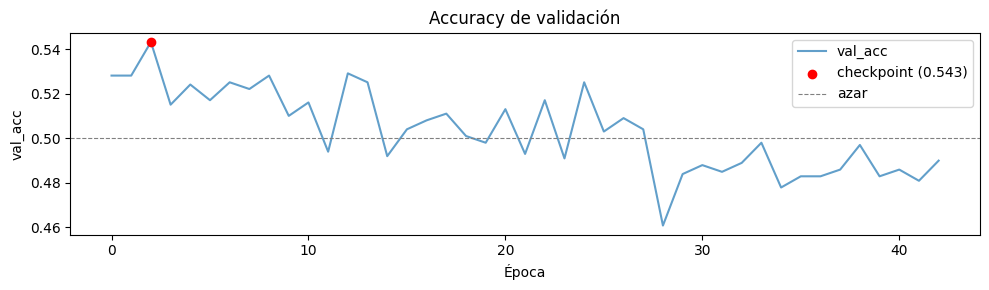


[6/6] Inferencia, semáforo y métricas...

Distribución de señales:
label
HOLD    836
BUY     230
SELL    169
Name: count, dtype: int64

Métricas de acierto (horizonte = 8 días):
   Señales totales      : 1235
   BUY / HOLD / SELL    : 230 / 836 / 169
   Cobertura (no-ámbar) : 0.323
   Accuracy direccional : 0.476
   Precisión BUY        : 0.622
   Precisión SELL       : 0.278
   Base 'siempre sube'  : 0.561   (listón a batir)
   Edge medio por señal : +0.00027

— Regresión del precio (día siguiente) —
   Modelo      : R²=0.9920 | RMSE=117.84 | MAE=88.90 | MAPE=1.024%
   Persistencia: R²=0.9934 | RMSE=107.07 | MAE=76.61 | MAPE=0.897%
   (un R²~0.98 es trivial: el baseline 'mañana=hoy' lo iguala)

— Barrido accuracy vs cobertura (tras filtro de tendencia) —
   cobertura_obj | cobertura_real | accuracy | BUY | SELL
        0.60      |     0.323      |  0.476  | 230 | 169
        0.50      |     0.265      |  0.459  | 185 | 142
        0.40      |     0.215      |  0.457  | 149 | 116
    

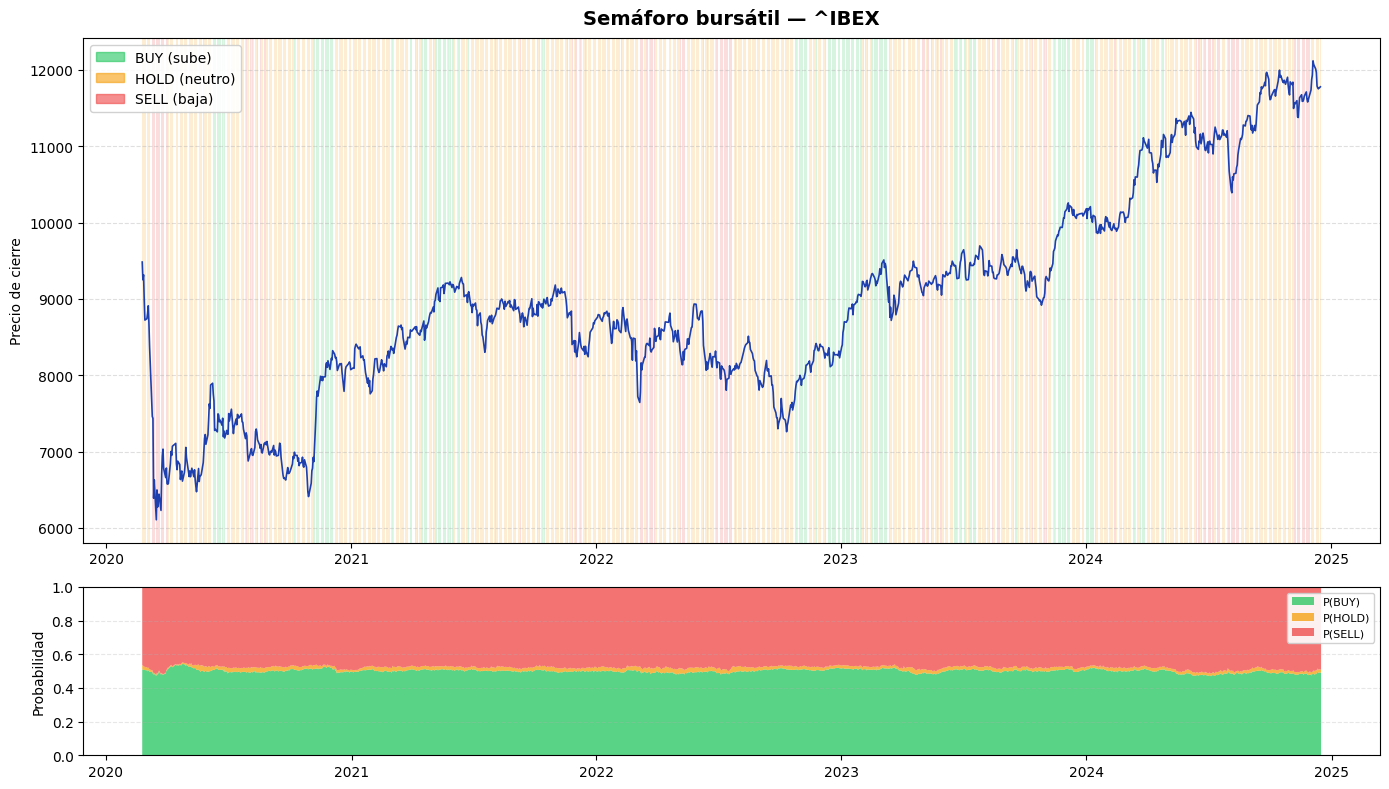

Gráfico guardado en semaforo_ibex.png

¡Pipeline completo!


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# EJECUCIÓN
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    main()
